<a href="https://colab.research.google.com/github/lama-byte/ML_for_cybersecurity/blob/main/Baseline%20Reproduction/Reproduce_Baseline_Excel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA)

In [ ]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier


# read datasets
excel_df = pd.read_csv("/content/Excel_Top10_Features.csv")


### Excel Documents Format

In [ ]:
excel_df.describe()

,entropy_of_text,macro_chr_count,macro_vocab_size,macro_arithmetic_operator_count,macro_token_count,macro_max_line_length,remote_template_present,numeric_cell_count,string_cell_count,avg_cell_length,label
count,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000
mean,5.084248,50.99000,6783.361800,5557.143100,6783.361800,508.895350,3.19295,5290.849100,10531.863500,52.781376,0.500000
std,1.166952,76.22718,7518.664676,8352.340038,7518.664676,1399.160047,7.90786,8168.264148,15409.635573,233.098514,0.500013
min,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,4.950348,0.00000,148.000000,6.000000,148.000000,36.000000,0.00000,3.000000,64.000000,10.939670,0.000000
50%,5.729341,3.00000,1934.000000,537.500000,1934.000000,39.000000,1.00000,630.000000,1078.000000,11.145632,0.500000
75%,5.750544,88.00000,14364.000000,9544.250000,14364.000000,89.000000,1.00000,9035.500000,18111.250000,11.349197,1.000000
max,8.310855,3249.00000,140313.000000,278507.000000,140313.000000,32759.000000,578.00000,447170.000000,470182.000000,14735.666667,1.000000


In [ ]:
excel_df.shape

(20000, 12)

In [ ]:
print(list(excel_df.columns))

['file_name', 'entropy_of_text', 'macro_chr_count', 'macro_vocab_size', 'macro_arithmetic_operator_count', 'macro_token_count', 'macro_max_line_length', 'remote_template_present', 'numeric_cell_count', 'string_cell_count', 'avg_cell_length', 'label']


In [ ]:
excel_df.head()

,file_name,entropy_of_text,macro_chr_count,macro_vocab_size,macro_arithmetic_operator_count,macro_token_count,macro_max_line_length,remote_template_present,numeric_cell_count,string_cell_count,avg_cell_length,label
0,benign_sample_3253.xlsx,5.746068,39,10079,4759,10079,38,1,4336,8926,11.184588,0
1,benign_sample_5685.xlsx,5.749956,287,19789,28783,19789,42,1,27138,54355,11.167818,0
2,benign_sample_8732.xlsx,5.745470,122,16084,12754,16084,38,1,12033,23997,11.132195,0
3,benign_sample_5743.xlsx,5.743675,152,17382,16244,17382,39,1,15217,30554,11.104673,0
4,benign_sample_5522.xlsx,5.748130,106,15452,11529,15452,38,1,10837,21622,11.151976,0


In [ ]:
# remote_template_present it's not a binary flag as it says on the paper !
excel_df['remote_template_present'].unique()

array([  1,   9,  17,  49,  10,  45, 205,  21,   8,  20,  59,  18,  44,
        24,  11,  15,  16,   7,  48,  13,  66,  12,  14,  43,  31,   5,
        86,  23,  91, 158,  64,  19, 146,  26, 155, 208, 238,  30,  22,
        29,  28,  32,  53, 113, 112,  51,  27, 141,   6,  38,  46, 157,
        40,   0,  50, 578])

for the above problem we will try to train the model on 2 cases, and then we will compare the results !
- the current feature as it is considering it's the count of external links in a document
- changing the values to binary instead of numeric making any non-zero value to 1


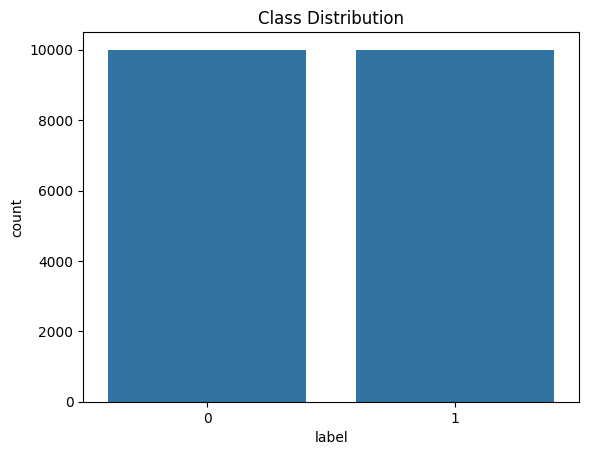

In [ ]:
# verify that the dataset is balanced (50% bengin, 50% malicious)

sns.countplot(data=excel_df, x="label")
plt.title("Class Distribution")
plt.show()

In [ ]:
benign_count = (excel_df["label"] == 0).sum()
malicious_count = (excel_df["label"] == 1).sum()

print("Benign:", benign_count)
print("Malicious:", malicious_count)

Benign: 10000
Malicious: 10000


<Axes: >

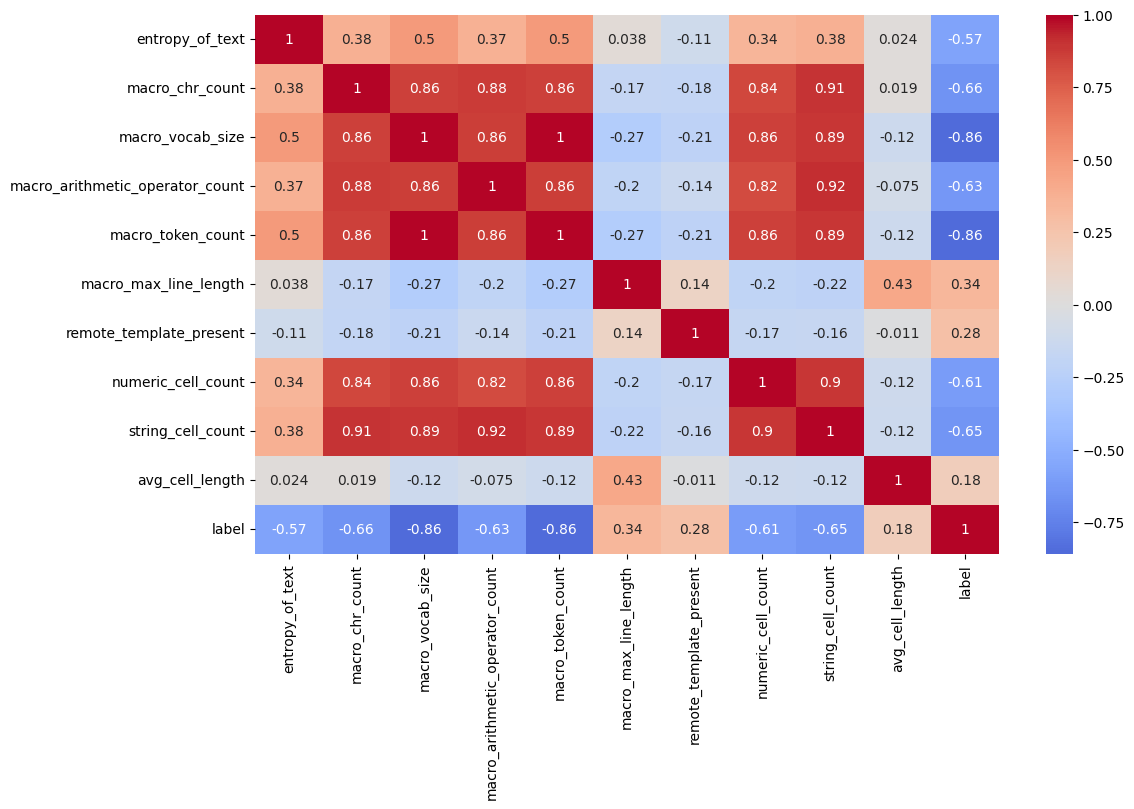

In [ ]:
# Correlation Heatmap (all features)

plt.figure(figsize=(12, 7))
corr = excel_df.drop(columns="file_name").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

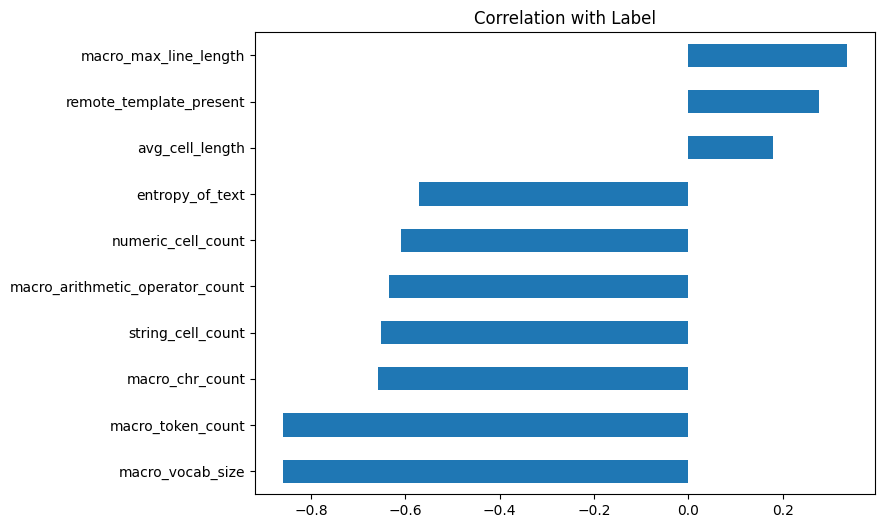

In [ ]:
# Correlation Heatmap for Label

corr = excel_df.drop(columns="file_name").corr()["label"].drop("label")

corr.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Correlation with Label")
plt.show()

# Note:
# (+) correlation → associated with malicious files.
# (-) correlation → associated with benign files.

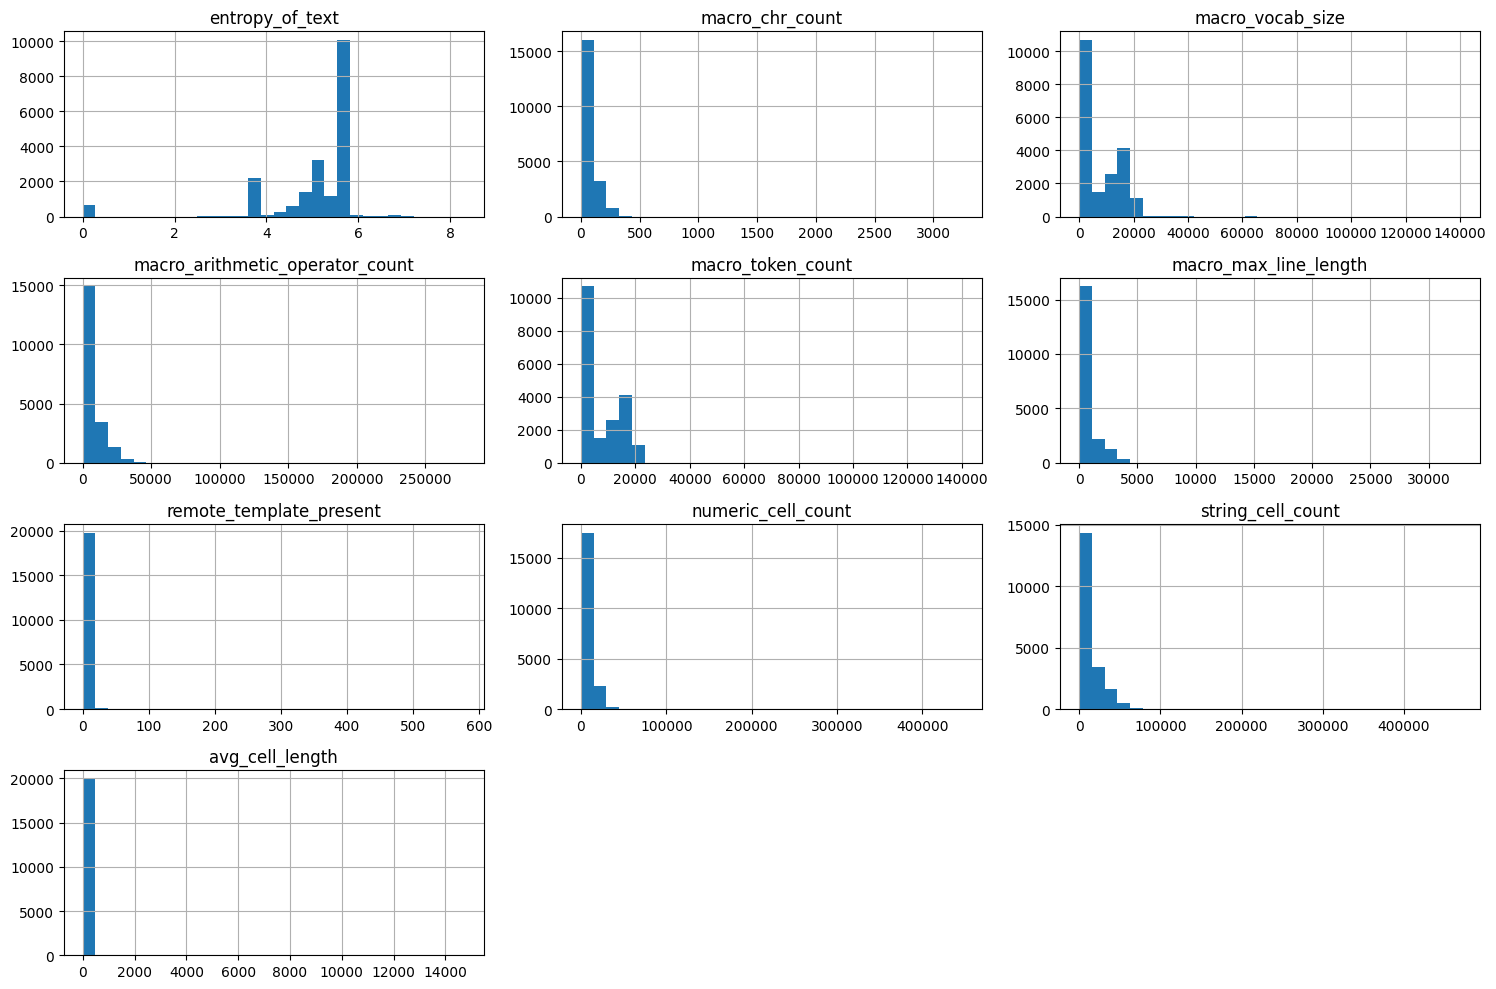

In [ ]:
# Histogram

excel_df.drop(columns=["file_name", "label"]).hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()

# X-axis = the values of the feature
# Y-axis = how many samples have values in that range

**Excel dataset observations**
- Samples are sorted (bengin then malicious) with file names
- 12 columns (10 features + file name col + label col)
- "remote_templete_present" feature is not a binary flag as mentioned in the paper, is it a conut of the remote templetes?
- Dataset is balanced (50% bengin, 50% malicious)


## *Reproduce the Baseline*



In [ ]:
X = excel_df.drop(columns=['file_name', 'label'])
X.columns
y = excel_df['label']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split (X, y, train_size=0.7, random_state=42, stratify=y)


### **1- Decision Tree**

In [ ]:
model_dt = DecisionTreeClassifier (random_state=42)
model_dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt = model_dt.predict(X_test)

In [ ]:
correct = 0

for actual, predicted in zip(y_test, y_pred_dt):
    if actual == predicted:
        correct += 1

print("Correct predictions:", correct)

Correct predictions: 5998


In [ ]:
accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt, average='macro')
recall = recall_score(y_test, y_pred_dt, average='macro')
f1 = f1_score(y_test, y_pred_dt, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9997
Precision: 0.9997
Recall: 0.9997
F1-score: 0.9997


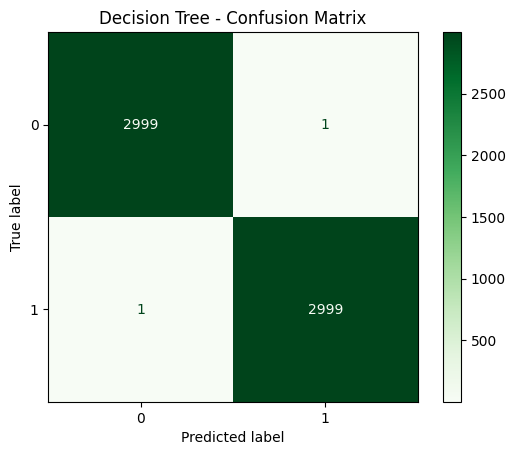

In [ ]:
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Greens")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

###**2- XGBoost**

In [ ]:
model_xg = XGBClassifier(random_state=42)
model_xg.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xg = model_xg.predict(X_test)

In [ ]:
correct = 0

for actual, predicted in zip(y_test, y_pred_xg):
    if actual == predicted:
        correct += 1

print("Correct predictions:", correct)

Correct predictions: 5998


In [ ]:
accuracy = accuracy_score(y_test, y_pred_xg)
precision = precision_score(y_test, y_pred_xg, average='macro')
recall = recall_score(y_test, y_pred_xg, average='macro')
f1 = f1_score(y_test, y_pred_xg, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9997
Precision: 0.9997
Recall: 0.9997
F1-score: 0.9997


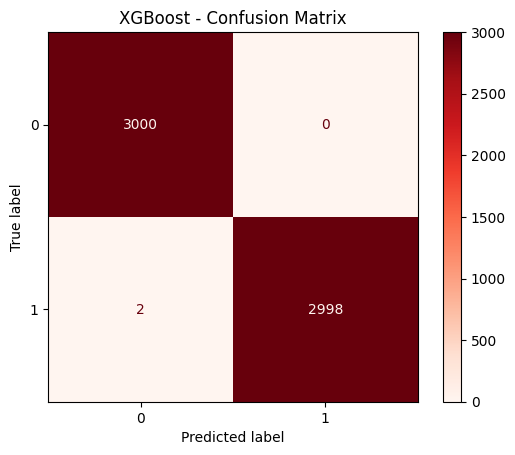

In [ ]:
cm = confusion_matrix(y_test, y_pred_xg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Reds")
plt.title("XGBoost - Confusion Matrix")
plt.show()

### **3- Random Forest**

In [ ]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit (X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = model_rf.predict(X_test)

In [ ]:
correct = 0

for actual, predicted in zip(y_test, y_pred_rf):
    if actual == predicted:
        correct += 1

print("Correct predictions:", correct)

Correct predictions: 5998


In [ ]:
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average='macro')
recall = recall_score(y_test, y_pred_rf, average='macro')
f1 = f1_score(y_test, y_pred_rf, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9997
Precision: 0.9997
Recall: 0.9997
F1-score: 0.9997


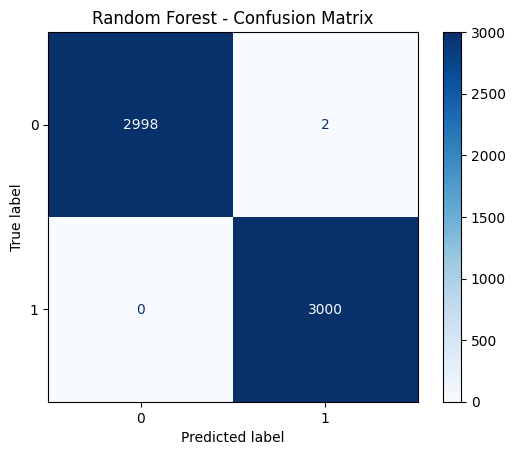

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.show()

---

check the results after changing to binary

In [ ]:
for idx in excel_df.index:
    if excel_df.loc[idx, 'remote_template_present'] != 0:
        excel_df.loc[idx, 'remote_template_present'] = 1

excel_df['remote_template_present'].unique()
excel_df['remote_template_present']


,remote_template_present
0,1
1,1
2,1
3,1
4,1
...,...
19995,0
19996,0
19997,0
19998,0


### **1- Decision Tree**

In [ ]:
model_dt = DecisionTreeClassifier (random_state=42)
model_dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt = model_dt.predict(X_test)

In [ ]:
correct = 0

for actual, predicted in zip(y_test, y_pred_dt):
    if actual == predicted:
        correct += 1

print("Correct predictions:", correct)

Correct predictions: 5998


In [ ]:
accuracy = accuracy_score(y_test, y_pred_dt)
precision = precision_score(y_test, y_pred_dt, average='macro')
recall = recall_score(y_test, y_pred_dt, average='macro')
f1 = f1_score(y_test, y_pred_dt, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9997
Precision: 0.9997
Recall: 0.9997
F1-score: 0.9997


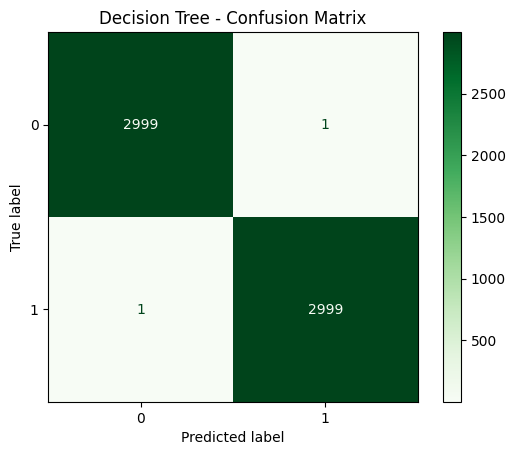

In [ ]:
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Greens")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

###**2- XGBoost**

In [ ]:
model_xg = XGBClassifier(random_state=42)
model_xg.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xg = model_xg.predict(X_test)

In [ ]:
correct = 0

for actual, predicted in zip(y_test, y_pred_xg):
    if actual == predicted:
        correct += 1

print("Correct predictions:", correct)

Correct predictions: 5998


In [ ]:
accuracy = accuracy_score(y_test, y_pred_xg)
precision = precision_score(y_test, y_pred_xg, average='macro')
recall = recall_score(y_test, y_pred_xg, average='macro')
f1 = f1_score(y_test, y_pred_xg, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9997
Precision: 0.9997
Recall: 0.9997
F1-score: 0.9997


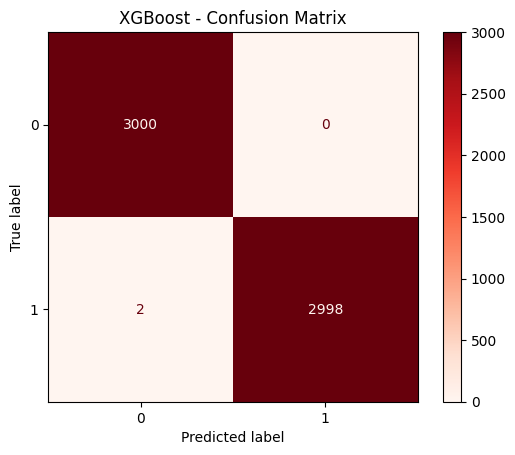

In [ ]:
cm = confusion_matrix(y_test, y_pred_xg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Reds")
plt.title("XGBoost - Confusion Matrix")
plt.show()

### **3- Random Forest**

In [ ]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit (X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = model_rf.predict(X_test)

In [ ]:
correct = 0

for actual, predicted in zip(y_test, y_pred_rf):
    if actual == predicted:
        correct += 1

print("Correct predictions:", correct)

Correct predictions: 5998


In [ ]:
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average='macro')
recall = recall_score(y_test, y_pred_rf, average='macro')
f1 = f1_score(y_test, y_pred_rf, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9997
Precision: 0.9997
Recall: 0.9997
F1-score: 0.9997


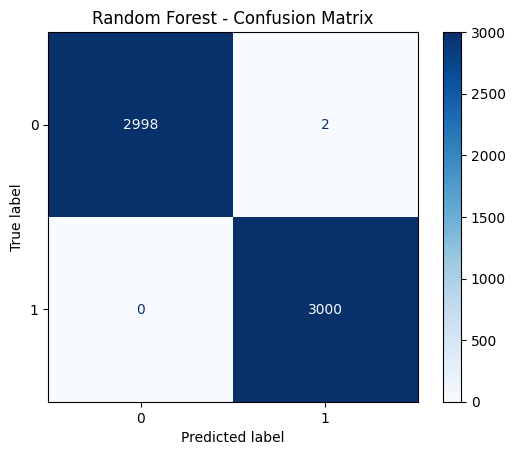

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.show()